<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
import os

output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [ ]:
# def load_data(directory: str):
#     data = []

#     all_files = np.array(
#         sorted(
#             glob(os.path.join(directory, "*.npz")),
#             key=lambda x: int(os.path.basename(x).replace(".npz", "")),
#         )
#     )

#     for file_name in all_files:
#         with np.load(file_name) as npz:
#             raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
#             img_tensor_raw = torch.as_tensor(raw_arr.data, dtype=torch.float)
#             img_tensor_mask = ~torch.as_tensor(raw_arr.mask) # Revert mask: 0 is invalid, 1 is valid
#             img_tensor_masked = torch.mul(img_tensor_raw, img_tensor_mask)
#         data.append(img_tensor_masked)

#     return data

In [8]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            # Create masked array
            raw_arr = np.ma.MaskedArray(
                data=npz['data'],
                mask=npz['mask']
            )

            # Raw tensor (KEEP values as-is)
            img_tensor = torch.as_tensor(raw_arr.data, dtype=torch.float32)

            # Mask: 1 = valid, 0 = invalid
            mask = ~torch.as_tensor(raw_arr.mask)

        # Store BOTH
        data.append((img_tensor, mask))

    return data

In [9]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [10]:
X_train_full_data = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [11]:
original_spectral_channels = X_train_full_data[0][0].shape[0]
print(f"Original spectral channels: {original_spectral_channels}")
reduced_spectral_channels = 3 # Number of channels after 1x1 convolution

Original spectral channels: 150


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train_full_data
original_indices = np.arange(len(X_train_full_data))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train_full_data, y_train, original_indices, test_size=0.2, random_state=93
)

# Then, split remaining 80% into train/val (20% val of original, means 25% of X_temp)
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.25, random_state=93
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1038
Validation patches: 347
Test patches: 347


In [14]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [14]:
# class NPZDataset(Dataset):
#     def __init__(self, tensor_list, labels, augment=True, size=(224,224)):
#         self.tensor_list = tensor_list
#         self.labels = labels
#         self.augment = augment
#         self.size = size

#         self.transform_aug = v2.Compose([
#             v2.Resize((224, 224)),
#             v2.RandomHorizontalFlip(p=0.5),
#             v2.GaussianNoise(mean=0.0, sigma=0.03),
#         ])

#         self.transform_basic = v2.Compose([
#             v2.Resize((224, 224)),
#         ])


#     def __len__(self):
#         return len(self.tensor_list)

#     def __getitem__(self, idx):
#         x = self.tensor_list[idx]

#         # # ---- Unconditionally resize to fixed size first ----
#         # # This ensures all tensors are of a consistent size before augmentation
#         # # and before being passed to the DataLoader's collate_fn.
#         # if x.shape[1] != self.size[0] or x.shape[2] != self.size[1]:
#         #     x = F.interpolate(
#         #         x.unsqueeze(0),  # add batch dim -> (1, C, H, W)
#         #         size=self.size,
#         #         mode='bilinear',
#         #         align_corners=False
#         #     ).squeeze(0)       # remove batch dim -> (C, H, W)

#         # ---- Apply augmentation ----
#         if self.augment:
#             x = self.transform_aug(x)
#         else:
#             x = self.transform_basic(x)

#         # ---- Per-channel normalization for CNN ----
#         x = (x - x.mean(dim=(1,2), keepdim=True)) / (x.std(dim=(1,2), keepdim=True) + 1e-6)

#         y = torch.tensor(self.labels[idx], dtype=torch.float32)
#         return x, y

In [15]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2


class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels, augment=True, size=(224, 224)):
        """
        tensor_list: list of tuples -> [(x, mask), ...]
                     x: (C, H, W)
                     mask: (C, H, W) with 1=valid, 0=invalid
        """
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size

        self.transform_aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.GaussianNoise(mean=0.0, sigma=0.03),
        ])

        #self.transform_basic = v2.Compose([])

    def __len__(self):
        return len(self.tensor_list)

    # 🔹 Crop (if too large) + Pad (if too small)
    def pad_to_size(self, x, mask):
        _, h, w = x.shape
        th, tw = self.size

        # ---- STEP 1: CROP if too large ----
        if h > th:
            start_h = (h - th) // 2
            x = x[:, start_h:start_h + th, :]
            mask = mask[:, start_h:start_h + th, :]
            h = th

        if w > tw:
            start_w = (w - tw) // 2
            x = x[:, :, start_w:start_w + tw]
            mask = mask[:, :, start_w:start_w + tw]
            w = tw

        # ---- STEP 2: PAD if too small ----
        pad_h = th - h
        pad_w = tw - w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
        mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

        return x, mask

    def normalize_with_mask(self, x, mask):
        # mask: 1 = valid, 0 = invalid

        valid_pixels = mask.sum(dim=(1, 2), keepdim=True)

        # ---- SAFETY: avoid empty masks ----
        valid_pixels_safe = valid_pixels.clamp(min=1)

        mean = (x * mask).sum(dim=(1, 2), keepdim=True) / valid_pixels_safe

        var = ((x - mean) * mask).pow(2).sum(dim=(1, 2), keepdim=True) / valid_pixels_safe

        std = torch.sqrt(var + 1e-6)

        # ---- SAFETY: avoid tiny std ----
        std = std.clamp(min=1e-3)

        x_norm = (x - mean) / std

        # ---- IMPORTANT: keep invalid pixels neutral ----
        x_norm = x_norm * mask

        # ---- OPTIONAL: fully zero-out empty samples ----
        x_norm = torch.where(valid_pixels == 0, torch.zeros_like(x_norm), x_norm)

        return x_norm

    def __getitem__(self, idx):
        x, mask = self.tensor_list[idx]

        # 1. FIX SIZE FIRST
        x, mask = self.pad_to_size(x, mask)

        # 2. NORMALIZE USING MASK
        x = self.normalize_with_mask(x, mask)

        # 3. REMOVE INVALID PIXELS (safe now)
        x = x * mask

        # 4. AUGMENTATION
        if self.augment:
            x = self.transform_aug(x)

        y = torch.tensor(self.labels[idx], dtype=torch.float32)

        return x, y

In [16]:
# -----------------------
# Create Dataset and DataLoader
# -----------------------

train_dataset = NPZDataset(X_train_final, y_train_final_scaled, augment=True)
val_dataset   = NPZDataset(X_val, y_val_scaled, augment=False)
test_dataset  = NPZDataset(X_test, y_test_scaled, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)


In [17]:
import torch
import torch.nn as nn
import timm

class HyperspectralRegressor(nn.Module):
    def __init__(
        self,
        original_in_channels: int = 150,
        reduced_in_channels: int = 10,
        n_outputs: int = 4,
        backbone_name: str = "efficientnet_b0",
        pretrained: bool = False,
        dropout: float = 0.3,
        regressor: nn.Module = None,
    ):
        """
        original_in_channels: Number of input spectral bands (masked pixels are zero).
        reduced_in_channels: Number of channels after 1x1 convolution.
        n_outputs: Number of regression outputs.
        backbone_name: Name of the model in timm.
        pretrained: Whether to load ImageNet weights (safe only if reduced_in_channels==3).
        """
        super().__init__()

        # 1x1 spectral reducer: Conv -> BN -> ReLU
        self.spectral_reducer = nn.Sequential(
            nn.Conv2d(original_in_channels, reduced_in_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(reduced_in_channels),
            nn.ReLU(inplace=True),
        )

        effective_pretrained = pretrained
        if pretrained and reduced_in_channels != 3:
            effective_pretrained = False

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=effective_pretrained,
            in_chans=reduced_in_channels,
            num_classes=0,
        )

        feat_dim = getattr(self.backbone, "num_features", None)
        if feat_dim is None:
            if hasattr(self.backbone, "fc") and hasattr(self.backbone.fc, "in_features"):
                feat_dim = self.backbone.fc.in_features
            else:
                raise RuntimeError("Backbone features cannot be determined")

        # Use provided regressor or default to the original one
        if regressor is None:
            self.regressor = nn.Sequential(
                nn.Linear(feat_dim, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(512, n_outputs),
            )
        else:
            self.regressor = regressor

        nn.init.kaiming_normal_(self.spectral_reducer[0].weight, nonlinearity="relu")
        if self.spectral_reducer[0].bias is not None:
            nn.init.zeros_(self.spectral_reducer[0].bias)

    def forward(self, x):
        """
        x: (B, original_in_channels, H, W)  -- masked pixels = 0
        returns: (B, n_outputs)
        """
        x = self.spectral_reducer(x)      # (B, reduced_in_channels, H, W)
        features = self.backbone(x)       # (B, feat_dim)
        out = self.regressor(features)    # (B, n_outputs)
        return out

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


## **Overfitting on one batch**

In [18]:
def overfit_single_batch(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    x_single: torch.Tensor,
    y_single: torch.Tensor,
    epochs: int = 800,
    device: torch.device = torch.device("cpu")
):
    """
    Performs overfitting of a model on a single batch of data.

    Args:
        model (nn.Module): The model to overfit.
        criterion (nn.Module): The loss function.
        optimizer (optim.Optimizer): The optimizer.
        x_single (torch.Tensor): The input features for the single batch.
        y_single (torch.Tensor): The target labels for the single batch.
        epochs (int): The number of epochs to train for.
        device (torch.device): The device (CPU/GPU) to run the training on.
    """
    print(f"\n--- Starting Overfitting on Single Batch for {epochs} epochs ---")

    x_single, y_single = x_single.to(device), y_single.to(device)

    for epoch_overfit in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs_overfit = model(x_single)
        loss_overfit = criterion(outputs_overfit, y_single)

        loss_overfit.backward()
        optimizer.step()

        if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
            print(f"Overfit Epoch {epoch_overfit+1}/{epochs} - Loss: {loss_overfit.item():.6f}")

    print("--- Overfitting complete ---")

In [19]:
train_data_single_batch = next(iter(train_loader))

In [20]:
train_data_single_batch[0].shape

torch.Size([16, 150, 224, 224])

In [21]:
train_data_single_batch[1].shape

torch.Size([16, 4])

In [24]:
import torch
import torch.nn as nn
import timm

# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    reduced_in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b0",
    pretrained=True  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting
optimizer_overfit = optim.AdamW(model_overfit.parameters(), lr=8e-5, weight_decay=1e-4)
criterion_overfit = nn.SmoothL1Loss(beta=1.0)

# Extract the single batch
x_single, y_single = train_data_single_batch
# Move x_single and y_single to the device for consistent usage
x_single = x_single.to(device)
y_single = y_single.to(device)

# Call the overfit_single_batch function
overfit_single_batch(
    model=model_overfit,
    criterion=criterion_overfit,
    optimizer=optimizer_overfit,
    x_single=x_single,
    y_single=y_single,
    epochs=500,
    device=device
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


--- Starting Overfitting on Single Batch for 500 epochs ---
Overfit Epoch 1/500 - Loss: 0.367982
Overfit Epoch 10/500 - Loss: 0.153438
Overfit Epoch 20/500 - Loss: 0.028646
Overfit Epoch 30/500 - Loss: 0.022504
Overfit Epoch 40/500 - Loss: 0.011767
Overfit Epoch 50/500 - Loss: 0.012133
Overfit Epoch 60/500 - Loss: 0.008524
Overfit Epoch 70/500 - Loss: 0.012264
Overfit Epoch 80/500 - Loss: 0.011155
Overfit Epoch 90/500 - Loss: 0.009532
Overfit Epoch 100/500 - Loss: 0.007496
Overfit Epoch 110/500 - Loss: 0.007890
Overfit Epoch 120/500 - Loss: 0.008617
Overfit Epoch 130/500 - Loss: 0.007020
Overfit Epoch 140/500 - Loss: 0.012237
Overfit Epoch 150/500 - Loss: 0.007597
Overfit Epoch 160/500 - Loss: 0.011868
Overfit Epoch 170/500 - Loss: 0.011670
Overfit Epoch 180/500 - Loss: 0.009193
Overfit Epoch 190/500 - Loss: 0.006037
Overfit Epoch 200/500 - Loss: 0.005139
Overfit Epoch 210/500 - Loss: 0.013205
Overfit Epoch 220/500 - Loss: 0.006087
Overfit Epoch 230/500 - Loss: 0.003726
Overfit Epoch 

In [25]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    outputs_single_batch = model_overfit(x_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[ 0.24855456  0.86155015 -0.50594026 -0.30335295]
 [ 0.42148864  0.08661735  0.08928099  0.07212973]
 [-0.3623512  -0.08870575 -0.41009307 -0.6866137 ]
 [-0.21845725  0.6413907   0.722129   -0.71658367]
 [-1.0761515  -0.8054763   1.002633   -1.0056489 ]
 [-0.0496511   2.322517    0.30170345  0.6020332 ]
 [ 0.19471917  0.06209264  0.344751    0.4320116 ]
 [ 0.8457926   0.13152115  0.39566326 -2.19355   ]
 [-0.18183678  0.04954391 -0.02094411  0.43528268]
 [ 0.35857484 -0.501901    0.02030449  0.04671014]
 [ 0.6808807  -0.5462427  -2.227417   -1.5030252 ]
 [ 0.20791826  1.148647    0.40892822 -1.3952485 ]
 [-0.17379445 -1.3821743  -0.8856714   0.02512347]
 [ 4.0145354   0.7246863   0.8520471   0.913418  ]
 [-1.0690523   0.20523117  2.833143    0.04284815]
 [ 0.00747147 -0.30813    -1.0342617  -0.62850356]]

True Values:
[[ 0.2562833   0.9098501  -0.5208116  -0.33005735]
 [ 0.4204686   0.07862084  0.08756958  0.06050299]
 [-

In [26]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 77.47875   280.09467   138.58665     6.7068377]
 [ 82.4292    233.481     162.06752     6.802977 ]
 [ 59.99085   222.935     142.36774     6.6087065]
 [ 64.109985  266.85165   187.0327      6.6010327]
 [ 39.55746   179.8199    198.0983      6.52702  ]
 [ 68.94226   367.97455   170.44736     6.938655 ]
 [ 75.93765   232.0058    172.14554     6.895122 ]
 [ 94.57541   236.18205   174.15398     6.222867 ]
 [ 65.15829   231.25096   157.71925     6.8959594]
 [ 80.62822   198.08052   159.34647     6.7964683]
 [ 89.85461   195.41328    70.67621     6.3996706]
 [ 76.31549   297.36407   174.67726     6.427266 ]
 [ 65.38851   145.13043   123.60667     6.790941 ]
 [185.28445   271.86206   192.15784     7.0183825]
 [ 39.760685  240.61584   270.31        6.79548  ]
 [ 70.57746   209.7362    117.744934    6.623585 ]]

Unscaled True Values:
[[ 77.7      283.       138.         6.7     ]
 

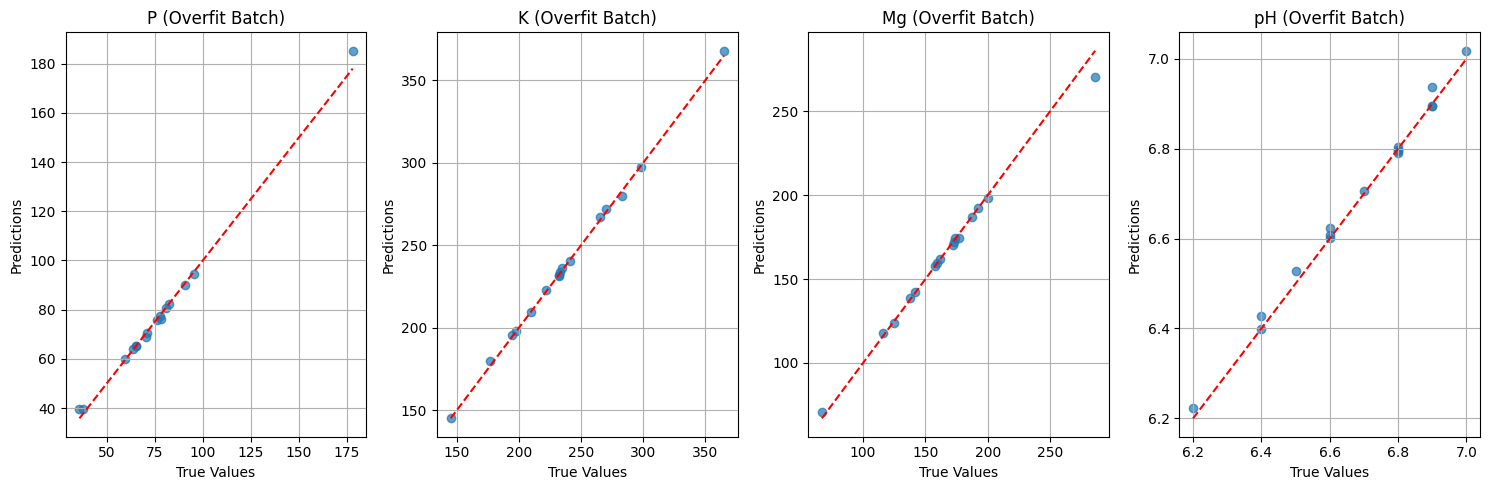

In [27]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


# **Training loop**

In [28]:
import os
import torch
from tqdm import tqdm

def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,            # ReduceLROnPlateau expected
    criterion,
    device,
    epochs=120,
    warmup_epochs=5,
    patience=20,
    save_path="best_hyperspectral_model.pth",
    use_amp=True, # Re-introduced use_amp parameter
    max_grad_norm=1.0,
    wandb_run=None
):
    # initial LRs per param_group (order must match how optimizer was created)
    initial_lrs = [pg['lr'] for pg in optimizer.param_groups]

    best_val_loss = float('inf')
    early_stop_counter = 0
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) # Re-introduced GradScaler initialization

    for epoch in range(epochs):
        # ---------- TRAIN ----------
        model.train()
        train_running_loss = 0.0
        train_samples = 0

        # linear warmup
        if epoch < warmup_epochs:
            warmup_factor = (epoch + 1) / float(warmup_epochs)
            for i, pg in enumerate(optimizer.param_groups):
                pg['lr'] = initial_lrs[i] * warmup_factor

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for xb, yb in loop:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
                preds = model(xb)
                loss = criterion(preds, yb)

            scaler.scale(loss).backward() # Re-introduced scaler.scale and backward

            # Calculate gradient norm before clipping
            # Unscale the gradients before clipping, if using AMP
            if use_amp:
                scaler.unscale_(optimizer)

            # Pass inf to just calculate norm, not clip
            #total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'))
            total_norm = torch.sqrt(
                sum(p.grad.detach().norm(2)**2 for p in model.parameters() if p.grad is not None)
            )

            # Clip gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            scaler.step(optimizer) # Re-introduced scaler.step
            scaler.update() # Re-introduced scaler.update

            bsz = xb.size(0)
            train_running_loss += loss.item() * bsz
            train_samples += bsz

            loop.set_postfix(
                train_loss=loss.item(),
                grad_norm=total_norm.item(), # Log gradient norm
                lr_backbone=optimizer.param_groups[0]['lr'],
                lr_head=optimizer.param_groups[1]['lr']
            )

        train_loss = train_running_loss / max(1, train_samples)

        # ---------- VALIDATION ----------
        model.eval()
        val_running_loss = 0.0
        val_samples = 0
        # optional threshold for logging outlier batches (set after first epoch if desired)
        outlier_threshold = None

        with torch.no_grad():
            for i, (xv, yv) in enumerate(val_loader):
                xv = xv.to(device, non_blocking=True)
                yv = yv.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
                    vpreds = model(xv)
                    vloss = criterion(vpreds, yv)

                bsz = xv.size(0)
                val_running_loss += vloss.item() * bsz
                val_samples += bsz

                # detect very large batch losses for debugging
                if outlier_threshold is not None and vloss.item() > outlier_threshold:
                    print(f"[DEBUG] Large val batch loss epoch {epoch+1} batch {i}: {vloss.item():.4f}")
                    # optionally save xv, yv, vpreds.cpu() for inspection

        val_loss = val_running_loss / max(1, val_samples)

        # ---------- SCHEDULER ----------
        # ReduceLROnPlateau expects scheduler.step(metric)
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            # if you use other schedulers, call scheduler.step() here (after warmup if needed)
            if epoch >= warmup_epochs - 1:
                scheduler.step()

        # ---------- LOGGING ----------
        current_lrs = [pg['lr'] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - backbone LR: {current_lrs[0]:.6f} - head LR: {current_lrs[1]:.6f}")

        if wandb_run is not None:
            wandb_run.log({
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch": epoch + 1,
                "lr_backbone": current_lrs[0],
                "lr_head": current_lrs[1],
                "grad_norm": total_norm.item() # Log gradient norm to wandb
            })

        # ---------- EARLY STOPPING & CHECKPOINT ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # save full checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if hasattr(scheduler, "state_dict") else None,
                "val_loss": val_loss,
            }, save_path)
            print(f"Saved best model (val_loss={val_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    # load best model if exists
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
    return model


In [29]:
# ----- Model -----
model = HyperspectralRegressor(
    reduced_in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b0",
    pretrained=True
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-6}, # Further Lowered LR
    {"params": model.regressor.parameters(), "lr": 2e-5},  # Further Lowered LR
], weight_decay=1e-4)

# ----- Loss -----
#criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss(beta=1.0)

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 35
patience = 10  # Increased early stopping patience
warmup_epochs = 5 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="hyperview_challenge efficientnet_b0 (pretrained=true), 1x1 cov, nn.SmoothL1Loss(beta=1.0)",
    config={
        "learning_rate_backbone": 5e-6, # Updated in config
        "learning_rate_head": 2e-5, # Updated in config
        "epochs": epochs,
        "batch_size": 16,
        "optimizer": "AdamW",
        "criterion": "SmoothL1Loss(beta=1.0)",
        "backbone": "efficientnet_b0",
        "1x1_conv_filters": 3,
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 5,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": patience,
        "use_amp": True
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses: (1) efficientnet_b0 backbone (pretreined=true), (2) 1x1 conv used, (3) nn.SmoothL1Loss(beta=1.0), (4)padding instead of resize (!), (5) batch size 4, (6) Automatic Mixed Precision enabled, (7) Lowered LRs and Increased Early Stopping Patience, (8) More robust normalize_with_mask."})


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ggasowski977 (ggasowski977-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [30]:
train_with_early_stopping(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer,
    scheduler = scheduler,            # ReduceLROnPlateau expected
    criterion = criterion,
    device = device,
    epochs  = epochs,
    warmup_epochs = warmup_epochs,
    patience = patience,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=wandb.run
)

# ----- Finish wandb -----
wandb.finish()

/tmp/ipykernel_1744/2820632558.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) # Re-introduced GradScaler initialization

Epoch 1/35:   0%|          | 0/65 [00:00<?, ?it/s]/tmp/ipykernel_1744/2820632558.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context

Epoch 1/35: 100%|██████████| 65/65 [02:18<00:00,  4.44s/it, grad_norm=2.62e+4, lr_backbone=1e-6, lr_head=4e-6, train_loss=0.402]
                                                                                                                                /tmp/ipykernel_1744/2820632558.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torc

Epoch 1/35 - Train Loss: 0.3888 - Val Loss: 2.7991 - backbone LR: 0.000001 - head LR: 0.000004
Saved best model (val_loss=2.7991)



Epoch 2/35: 100%|██████████| 65/65 [01:54<00:00,  1.64s/it, grad_norm=2.64e+4, lr_backbone=2e-6, lr_head=8e-6, train_loss=0.557]
                                                                                                                                

Epoch 2/35 - Train Loss: 0.3847 - Val Loss: 4.7371 - backbone LR: 0.000002 - head LR: 0.000008



Epoch 3/35: 100%|██████████| 65/65 [01:54<00:00,  1.64s/it, grad_norm=3.33e+4, lr_backbone=3e-6, lr_head=1.2e-5, train_loss=0.349]
                                                                                                                                  /tmp/ipykernel_1744/2820632558.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context
/tmp/ipykernel_1744/2820632558.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp): # Re-introduced torch.cuda.amp.autocast context


...

Epoch 9/35 - Train Loss: 0.3710 - Val Loss: 20.7782 - backbone LR: 0.000002 - head LR: 0.000006



Epoch 10/35: 100%|██████████| 65/65 [01:56<00:00,  1.67s/it, grad_norm=3.65e+4, lr_backbone=1.5e-6, lr_head=6e-6, train_loss=0.345]
                                                                                                                                   

Epoch 10/35 - Train Loss: 0.3722 - Val Loss: 26.0600 - backbone LR: 0.000002 - head LR: 0.000006



Epoch 11/35:   6%|▌         | 4/65 [00:08<01:42,  1.67s/it, grad_norm=5.24e+4, lr_backbone=1.5e-6, lr_head=6e-6, train_loss=0.283]
                                                                                                                                  

KeyboardInterrupt: 

In [31]:
# ----- Load best model -----
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## **Evaluate results in comparision to the Baseline Regressor.**

In [32]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [33]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the local test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            preds_batch = model(X_batch_test)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [34]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][1].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [35]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train_full_data[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_test_nonpca]) # Accessing the image tensor from tuple

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train_full_data[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_combined_train_val_nonpca]) # Accessing the image tensor from tuple

In [36]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [37]:
# Load the best model weights
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [38]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 16403.1113, Baseline MSE = 956.1005, Normalized = 17.1563
K: Model MSE = 80202.4688, Baseline MSE = 3448.3214, Normalized = 23.2584
Mg: Model MSE = 215287.8125, Baseline MSE = 1448.3911, Normalized = 148.6393
pH: Model MSE = 4.7535, Baseline MSE = 0.0677, Normalized = 70.2471

Challenge normalized score (lower is better, on local test set): 64.8253


Per-target comparison (on local test set from training data):
P: Model MSE = 16403.1113, Baseline MSE = 956.1005, Normalized = 17.1563
K: Model MSE = 80202.4688, Baseline MSE = 3448.3214, Normalized = 23.2584
Mg: Model MSE = 215287.8125, Baseline MSE = 1448.3911, Normalized = 148.6393
pH: Model MSE = 4.7535, Baseline MSE = 0.0677, Normalized = 70.2471

Challenge normalized score (lower is better, on local test set): 64.8253


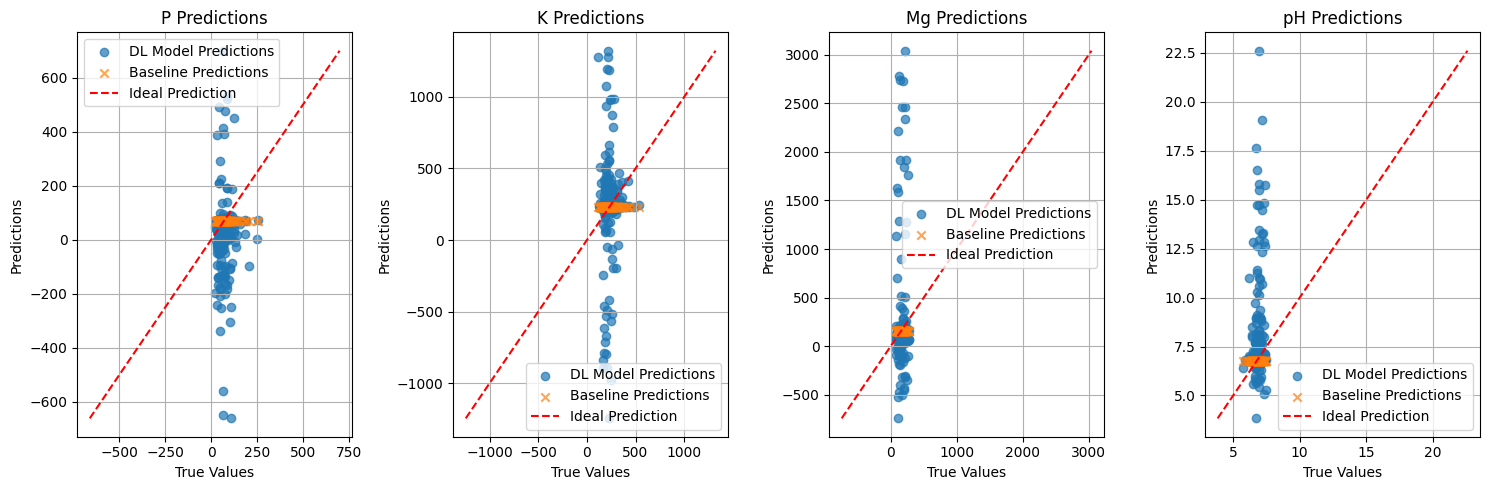

In [39]:
# Load the best model weights for the deep learning model
#model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

In [40]:
def display_predictions_table(model, test_loader, scaler_y, device):
    """Displays the model's predictions against ground truth values in a tabular form (unscaled)."""
    model.eval()  # Set the model to evaluation mode
    all_predictions_scaled = []
    all_true_values_scaled = []

    with torch.no_grad():
        for X_batch, y_batch_true_scaled in test_loader:
            X_batch = X_batch.to(device)
            preds_batch = model(X_batch)
            all_predictions_scaled.append(preds_batch.cpu().numpy())
            all_true_values_scaled.append(y_batch_true_scaled.cpu().numpy())

    # Concatenate all batches
    y_predictions_scaled = np.vstack(all_predictions_scaled)
    y_true_scaled = np.vstack(all_true_values_scaled)

    # Inverse transform to get original values
    y_predictions_unscaled = scaler_y.inverse_transform(y_predictions_scaled)
    y_true_unscaled = scaler_y.inverse_transform(y_true_scaled)

    # Create a DataFrame for display
    target_names = ["P", "K", "Mg", "pH"]

    # To ensure consistent number of samples, we'll just take a few examples from the test set
    num_samples_to_display = min(10, len(y_predictions_unscaled))

    # Correctly build the dictionary for DataFrame
    data_for_df = {}
    for i, name in enumerate(target_names):
        data_for_df[f'True {name}'] = y_true_unscaled[:num_samples_to_display, i]
        data_for_df[f'Pred {name}'] = y_predictions_unscaled[:num_samples_to_display, i]

    df_display = pd.DataFrame(data_for_df)

    print(f"\nSample of {num_samples_to_display} Predictions vs. True Values (Unscaled):")
    display(df_display)

# Example usage of the function:
display_predictions_table(model, test_loader, scaler_y, device)



Sample of 10 Predictions vs. True Values (Unscaled):


,True P,Pred P,True K,Pred K,True Mg,Pred Mg,True pH,Pred pH
0,64.599998,72.471550,243.0,235.308395,184.000000,160.423370,6.50,6.791874
1,36.099998,30.671091,193.0,242.664230,77.200005,99.965149,5.73,6.397818
2,56.400002,47.283066,213.0,204.136459,154.000000,121.875923,6.70,6.847342
3,46.500000,-0.243678,146.0,401.152130,116.000000,60.097313,6.90,7.210262
4,57.599998,70.138870,234.0,230.642914,167.000000,161.908844,6.40,6.794224
5,68.400002,390.391022,230.0,-420.978455,220.000000,3040.191406,6.80,12.647256
6,35.500000,71.233582,132.0,227.009689,120.000000,160.037979,6.80,6.816440
7,96.199997,70.232559,226.0,226.584976,140.000000,159.303055,6.80,6.789868
8,45.400002,70.010658,209.0,243.146774,143.000000,158.631042,6.80,6.862990
9,123.000000,35.827801,363.0,297.395935,195.000000,121.433624,6.96,7.323870


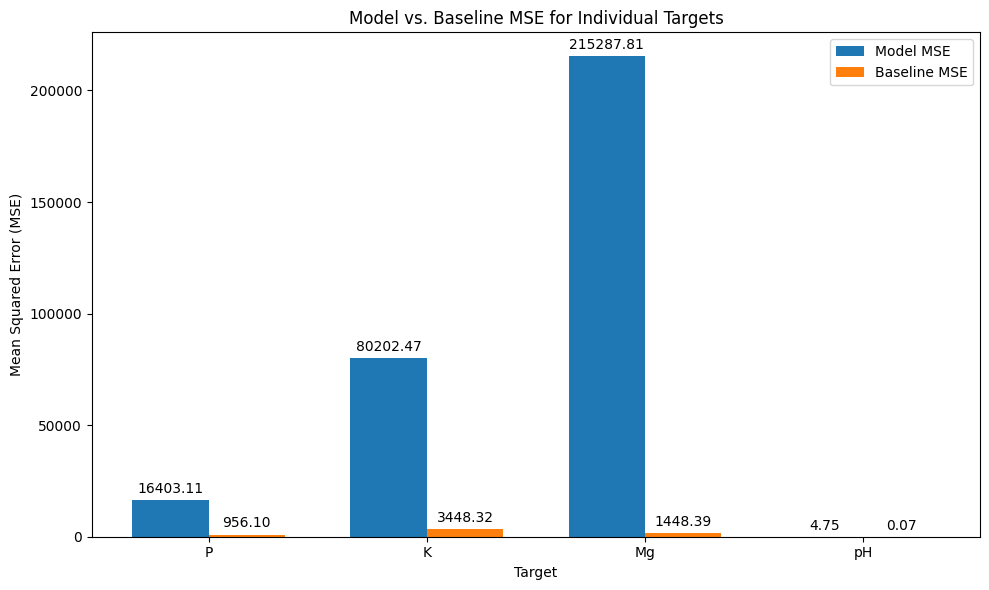

In [41]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [ ]:
display_predictions_table(model, test_loader, scaler_y, device)